# Expected WAR (xWAR) — Position Players, v5
### Linear Regression vs Random Forest vs XGBoost, with empirically calibrated `WOBA_SCALE` / `RUNS_PER_WIN`

**Why this calibration works as plain linear regression:** once `xwoba` is fixed (already predicted by
whichever model), everything downstream is algebra:

```
batting_runs = (xwoba - league_woba) * pa / WOBA_SCALE
RAR          = batting_runs + xbsr + fielding_runs + pos_adj_runs + replacement_runs
xWAR         = RAR / RUNS_PER_WIN
```

Substituting, `xWAR` is *linear* in two unknowns:

```
xWAR = c1 * raw_woba_diff_term + c2 * other_runs
  where  c1 = 1 / (WOBA_SCALE * RUNS_PER_WIN)
         c2 = 1 / RUNS_PER_WIN
         raw_woba_diff_term = (xwoba - league_woba) * pa
         other_runs         = xbsr + fielding_runs + pos_adj_runs + replacement_runs
```

So a no-intercept OLS fit of `war ~ raw_woba_diff_term + other_runs` gives the exact, closed-form,
MSE-minimizing `WOBA_SCALE` and `RUNS_PER_WIN` — no grid search needed.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from xgboost import XGBRegressor

pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

## Step 1 — Load and clean

- Convert percent-string columns to floats
- Fix the join-duplication artifact (a faulty merge produced a cartesian product of rows for at least
  one mid-season traded player) by deduplicating on `(player_id, season, position, team)` **before**
  aggregating
- Collapse multi-position rows into one row per player-season, summing OAA across positions
- Only aggregate the columns the finalized models actually use (`ev`, `maxev`, `pull`, `sb_pct` are no
  longer pulled through, since none of the four are used downstream anymore)

In [2]:
df = pd.read_csv('expectedwarhitters.csv', na_values=['null'])
print('Raw shape:', df.shape)
df.head()

Raw shape: (1935, 37)


,season,name,team,position,age,pa,bb,k,woba,bsr,...,sb%,age.1,frm,oaa,player_id,team_id,competitive_runs,bolts,hp_to_1b,sprint_speed
0,2022,Aaron Hicks,NYY,CF,32,453,13.70%,24.10%,0.2920,0.6000,...,0.7692,32,0.0000,1,543305,147,128,0,4.2600,27.9000
1,2022,Aaron Hicks,NYY,CF,32,453,13.70%,24.10%,0.2920,0.6000,...,0.7692,32,0.0000,-1,543305,147,128,0,4.2600,27.9000
2,2023,Aaron Hicks,BAL,CF,33,312,13.50%,22.10%,0.3260,1.1000,...,1.0000,33,0.0000,-1,543305,110,111,0,4.3300,27.3000
3,2021,Aaron Judge,NYY,RF,29,633,11.80%,25.00%,0.3870,0.2000,...,0.8571,29,0.0000,0,592450,147,189,1,4.6500,27.7000
4,2022,Aaron Judge,NYY,CF,30,696,15.90%,25.10%,0.4580,1.0000,...,0.8421,30,0.0000,2,592450,147,184,0,4.6600,27.3000


In [3]:
# --- Convert percent-string columns ('23.4%' -> 0.234) ---
pct_cols = ['bb', 'k', 'barrel', 'hardhit', 'ld', 'gb', 'fb', 'pull',
            'h_swing', 'c_swing', 's_swing', 'w_swing']
for col in pct_cols:
    df[col] = df[col].astype(str).str.rstrip('%').astype(float) / 100

df.rename(columns={'bb': 'bb_pct', 'k': 'k_pct', 'barrel': 'barrel_pct'}, inplace=True)

In [4]:
# --- Fix the join-duplication artifact ---
# A faulty merge on mid-season trades produced a cartesian product of rows for some
# player-seasons. Collapsing exact (player, season, position, team) duplicates BEFORE
# aggregating prevents those rows from being double-counted in the sums/means below.
dedup_pos = df.groupby(['player_id', 'season', 'position', 'team'], as_index=False).first()

# --- Aggregate to one row per player-season ---
# OAA is summed across positions (multi-position players); everything else that should
# be constant within a player-season is taken with 'first'. Only columns the finalized
# models use are kept -- ev, maxev, pull, and sb_pct are dropped from the aggregation.
agg = dedup_pos.groupby(['player_id', 'season'], as_index=False).agg(
    name=('name', 'first'), pa=('pa', 'first'), age=('age', 'first'),
    bb_pct=('bb_pct', 'first'), k_pct=('k_pct', 'first'), barrel_pct=('barrel_pct', 'first'),
    sprint_speed=('sprint_speed', 'mean'), oaa=('oaa', 'sum'),
    woba=('woba', 'first'), bsr=('bsr', 'first'), war=('war', 'first'),
    pos=('position', 'first'), frm=('frm', 'max'),
    sb=('sb', 'first'), cs=('cs', 'first'),
    hardhit=('hardhit', 'first'), ev90=('ev90', 'first'),
    la=('la', 'first'), ld=('ld', 'first'), fb=('fb', 'first'),
)

master = agg.dropna(subset=['sprint_speed', 'barrel_pct', 'woba', 'bsr']).reset_index(drop=True)
master['is_catcher'] = master['pos'] == 'C'

print('Cleaned shape:', master.shape)
print(master['season'].value_counts().sort_index())

Cleaned shape: (1793, 23)
season
2021    361
2022    358
2023    362
2024    364
2025    348
Name: count, dtype: int64


## Step 2 — Train / test split

One split, used consistently everywhere downstream: for fitting every model (hitting, baserunning) and
for the empirical calibration of `WOBA_SCALE` / `RUNS_PER_WIN`. This keeps every R² comparison
apples-to-apples and prevents the calibration step from leaking test-set information.

In [5]:
train_idx, test_idx = train_test_split(master.index, test_size=0.20, random_state=42)
train = master.loc[train_idx].copy()
test = master.loc[test_idx].copy()

league_woba = master.groupby('season')['woba'].mean()

print(f'Train: {len(train)} player-seasons   Test: {len(test)} player-seasons')

Train: 1434 player-seasons   Test: 359 player-seasons


## Step 3 — Hitting models: BB%, K%, Barrel% + batted-ball profile → xwOBA

Three models fit on identical features, compared on identical held-out data:
- **Linear Regression** — fully interpretable coefficients, no tuning
- **Random Forest** — captures non-linearity/interactions, more variance-prone on a small feature set
- **XGBoost** — boosted trees, the other non-linear candidate

**Feature set (v5):** `ev`, `maxev`, and `pull` have been removed after a significance/VIF review —
see the v5 changelog at the top of this notebook. The remaining eight features are all significant at
p < 0.06 against wOBA, with `ev90` retained as the single exit-velocity signal (it dominated `ev` and
`maxev` on both significance and VIF).

In [6]:
hit_features = [
    'bb_pct', 'k_pct', 'barrel_pct',
    'hardhit', 'ev90',
    'la', 'ld', 'fb'
]

X_train_hit, y_train_hit = train[hit_features], train['woba']
X_test_hit, y_test_hit = test[hit_features], test['woba']

In [7]:
# --- Linear Regression ---
lin_hit = LinearRegression().fit(X_train_hit, y_train_hit)

# --- Random Forest ---
rf_hit = RandomForestRegressor(
    n_estimators=500, max_depth=15, random_state=42, n_jobs=-1
).fit(X_train_hit, y_train_hit)

# --- XGBoost ---
xgb_hit = XGBRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
).fit(X_train_hit, y_train_hit)

# Predict xwOBA for everyone (train + test), needed downstream for batting_runs
for tag, model in [('lin', lin_hit), ('rf', rf_hit), ('xgb', xgb_hit)]:
    train[f'xwoba_{tag}'] = model.predict(X_train_hit)
    test[f'xwoba_{tag}'] = model.predict(X_test_hit)

hit_r2 = {
    'Linear Regression': r2_score(y_test_hit, test['xwoba_lin']),
    'Random Forest':     r2_score(y_test_hit, test['xwoba_rf']),
    'XGBoost':            r2_score(y_test_hit, test['xwoba_xgb']),
}

print('Hitting model -- held-out wOBA R^2')
for name, r2 in hit_r2.items():
    print(f'  {name:<20s} {r2:.4f}')

Hitting model -- held-out wOBA R^2
  Linear Regression    0.7042
  Random Forest        0.6383
  XGBoost              0.6580


**Linear Regression coefficients** (interpretable as \"wOBA points of value per unit of stat\"):

In [8]:
print('Linear hitting model coefficients:')
for feat, coef in zip(hit_features, lin_hit.coef_):
    print(f'  {feat:<10s} {coef:+.4f}')
print('Intercept:', round(lin_hit.intercept_, 4))

Linear hitting model coefficients:
  bb_pct     +0.2848
  k_pct      -0.3312
  barrel_pct +0.6106
  hardhit    +0.0038
  ev90       +0.0018
  la         +0.0011
  ld         +0.2299
  fb         -0.1049
Intercept: 0.1015


## Step 4 — Baserunning models: Sprint Speed, xwOBA + SB/CS → xBsR

Same three-model comparison. Each model's baserunning fit uses **that same model's own predicted
`xwoba`** as a feature (not a different model's), so the lin/rf/xgb pipelines stay fully self-contained
end to end.

**Feature set (v5):** `sb_pct` has been removed — with `sb` and `cs` already in the model as raw
counts, `sb_pct` was redundant (it's a direct function of the two) and added no independent signal.
The remaining four features (`sprint_speed`, `xwoba`, `sb`, `cs`) are all significant at p < 0.001.

In [9]:
def fit_baserunning(tag, model_class, **kwargs):
    feats = ['sprint_speed', f'xwoba_{tag}', 'sb', 'cs']
    model = model_class(**kwargs).fit(train[feats], train['bsr'])
    train[f'xbsr_{tag}'] = model.predict(train[feats])
    test[f'xbsr_{tag}'] = model.predict(test[feats])
    return model

lin_run = fit_baserunning('lin', LinearRegression)
rf_run  = fit_baserunning('rf',  RandomForestRegressor, n_estimators=500, max_depth=10,
                           random_state=42, n_jobs=-1)
xgb_run = fit_baserunning('xgb', XGBRegressor, n_estimators=500, max_depth=4, learning_rate=0.05,
                           subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

run_r2 = {
    'Linear Regression': r2_score(test['bsr'], test['xbsr_lin']),
    'Random Forest':     r2_score(test['bsr'], test['xbsr_rf']),
    'XGBoost':            r2_score(test['bsr'], test['xbsr_xgb']),
}

print('Baserunning model -- held-out BsR R^2')
for name, r2 in run_r2.items():
    print(f'  {name:<20s} {r2:.4f}')

Baserunning model -- held-out BsR R^2
  Linear Regression    0.6752
  Random Forest        0.6501
  XGBoost              0.6242


## Step 5 — Fielding runs

Not model-dependent — FRM is already in runs for catchers, and OAA is converted to runs using
Statcast's own published conversion (0.90 runs/out for outfielders, 0.75 runs/out for infielders).
Computed once and shared across all three model pipelines.

In [10]:
OAA_TO_RUNS = {
    '1B': 0.75, '2B': 0.75, '3B': 0.75, 'SS': 0.75,   # infield
    'LF': 0.90, 'CF': 0.90, 'RF': 0.90,                # outfield
}

for d in (train, test):
    d['oaa_run_factor'] = d['pos'].map(OAA_TO_RUNS).fillna(0.80)
    d['oaa_runs'] = d['oaa'] * d['oaa_run_factor']
    d['fielding_runs'] = np.where(d['is_catcher'], d['frm'], d['oaa_runs']).astype(float)
    d['fielding_runs'] = d['fielding_runs'].fillna(0)

## Step 6 — Positional adjustment and replacement level

Also model-independent — standard runs-per-600-PA constants, scaled by playing time.

In [11]:
POSITIONAL_ADJ_PER_600 = {
    'C': 9.5, '1B': -9.5, '2B': 2.5, '3B': 2.0, 'SS': 7.5,
    'LF': -7.0, 'CF': 2.5, 'RF': -7.0, 'DH': -15.0
}
REPLACEMENT_RUNS_PER_600 = 20.0

for d in (train, test):
    d['pos_adj_runs'] = d['pos'].map(POSITIONAL_ADJ_PER_600).fillna(0) * (d['pa'] / 600)
    d['replacement_runs'] = REPLACEMENT_RUNS_PER_600 * (d['pa'] / 600)

## Step 7 — Empirically calibrate `WOBA_SCALE` and `RUNS_PER_WIN` (per model)

Instead of the FanGraphs Guts placeholders (`WOBA_SCALE = 1.20`, `RUNS_PER_WIN = 9.0`), we solve for
the values that minimize error against **actual WAR**, fit **separately for each model's pipeline**
(lin / rf / xgb each get their own constants, since their `xwoba`/`xbsr` scales differ slightly).

Recall the linear identity:

```
xWAR = c1 * raw_woba_diff_term + c2 * other_runs
  c1 = 1 / (WOBA_SCALE * RUNS_PER_WIN)
  c2 = 1 / RUNS_PER_WIN
```

`fit_intercept=False` is intentional: there's no intercept term in the real model structure (xWAR = 0
when both run components are 0), so allowing an intercept would mask bias rather than calibrate the
actual constants. Fit on **train only**; we validate on test afterward exactly like every other model
choice in this notebook.

In [12]:
def calibrate_constants(tag):
    """Solve for WOBA_SCALE and RUNS_PER_WIN that minimize squared error vs actual WAR,
    for one model's (lin/rf/xgb) xwoba + xbsr pipeline. Fit on train, return constants
    plus train/test R^2 for sanity-checking."""
    for d in (train, test):
        d['league_woba'] = d['season'].map(league_woba)
        d[f'raw_woba_diff_term_{tag}'] = (d[f'xwoba_{tag}'] - d['league_woba']) * d['pa']
        d[f'other_runs_{tag}'] = (
            d[f'xbsr_{tag}'] + d['fielding_runs'] + d['pos_adj_runs'] + d['replacement_runs']
        )

    calib_cols = [f'raw_woba_diff_term_{tag}', f'other_runs_{tag}']
    calib_model = LinearRegression(fit_intercept=False).fit(train[calib_cols], train['war'])
    c1, c2 = calib_model.coef_

    woba_scale = c2 / c1
    runs_per_win = 1 / c2

    train_r2 = calib_model.score(train[calib_cols], train['war'])
    test_r2 = calib_model.score(test[calib_cols], test['war'])

    return {
        'tag': tag, 'WOBA_SCALE': woba_scale, 'RUNS_PER_WIN': runs_per_win,
        'calib_train_r2': train_r2, 'calib_test_r2': test_r2,
    }

calibration = {tag: calibrate_constants(tag) for tag in ['lin', 'rf', 'xgb']}

calib_df = pd.DataFrame(calibration.values()).set_index('tag')
print(calib_df.round(4))

     WOBA_SCALE  RUNS_PER_WIN  calib_train_r2  calib_test_r2
tag                                                         
lin      1.2620        9.5584          0.7670         0.8034
rf       1.0580       10.0598          0.9255         0.7814
xgb      1.1282        9.9516          0.9006         0.7880


**Sanity checks worth running on the output above:**
- If `calib_test_r2` is much lower than `calib_train_r2`, the constants may be overfit to train-set
  noise (unlikely with only 2 free parameters, but check anyway).
- If `WOBA_SCALE` lands far outside the real-world ~1.15–1.25 range, that's a sign `raw_woba_diff_term`
  and `other_runs` are collinear enough that the fit is trading off between the two coefficients rather
  than recovering a meaningful ratio — check with `train[[f'raw_woba_diff_term_{tag}', f'other_runs_{tag}']].corr()`.
- These constants make *this specific model's* RAR map onto actual WAR as well as possible — they are
  not an independent re-derivation of the true FanGraphs Guts constants, since any bias already baked
  into the positional/fielding constants gets partially absorbed into `RUNS_PER_WIN` here.

## Step 8 — Compute RAR and xWAR for all three models

Each model uses its **own** calibrated `WOBA_SCALE` / `RUNS_PER_WIN` from Step 7.

In [13]:
def compute_xwar(d, tag):
    c = calibration[tag]
    batting_runs = d[f'raw_woba_diff_term_{tag}'] / c['WOBA_SCALE']
    rar = batting_runs + d[f'other_runs_{tag}']
    return rar, rar / c['RUNS_PER_WIN']

for d in (train, test):
    for tag in ['lin', 'rf', 'xgb']:
        d[f'RAR_{tag}'], d[f'xWAR_{tag}'] = compute_xwar(d, tag)

## Step 9 — Model comparison (held-out test set)

Final scorecard: hitting R², baserunning R², end-to-end xWAR R², xWAR correlation, and xWAR MAE — all
on test, all using each model's own calibrated constants.

In [14]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'wOBA_R2': [hit_r2['Linear Regression'], hit_r2['Random Forest'], hit_r2['XGBoost']],
    'BsR_R2':  [run_r2['Linear Regression'], run_r2['Random Forest'], run_r2['XGBoost']],
    'xWAR_R2': [r2_score(test['war'], test[f'xWAR_{t}']) for t in ['lin', 'rf', 'xgb']],
    'xWAR_corr': [test[['war', f'xWAR_{t}']].corr().iloc[0, 1] for t in ['lin', 'rf', 'xgb']],
    'xWAR_MAE': [mean_absolute_error(test['war'], test[f'xWAR_{t}']) for t in ['lin', 'rf', 'xgb']],
    'WOBA_SCALE': [calibration[t]['WOBA_SCALE'] for t in ['lin', 'rf', 'xgb']],
    'RUNS_PER_WIN': [calibration[t]['RUNS_PER_WIN'] for t in ['lin', 'rf', 'xgb']],
})

print('MODEL COMPARISON -- held-out test set, each model with its own calibrated constants')
print('=' * 95)
print(results.round(4).to_string(index=False))

MODEL COMPARISON -- held-out test set, each model with its own calibrated constants
            Model  wOBA_R2  BsR_R2  xWAR_R2  xWAR_corr  xWAR_MAE  WOBA_SCALE  RUNS_PER_WIN
Linear Regression   0.7042  0.6752   0.8034     0.9001    0.6882      1.2620        9.5584
    Random Forest   0.6383  0.6501   0.7814     0.8859    0.7141      1.0580       10.0598
          XGBoost   0.6580  0.6242   0.7880     0.8883    0.7020      1.1282        9.9516


## Step 10 — Validation: xWAR vs actual WAR, all three models side by side

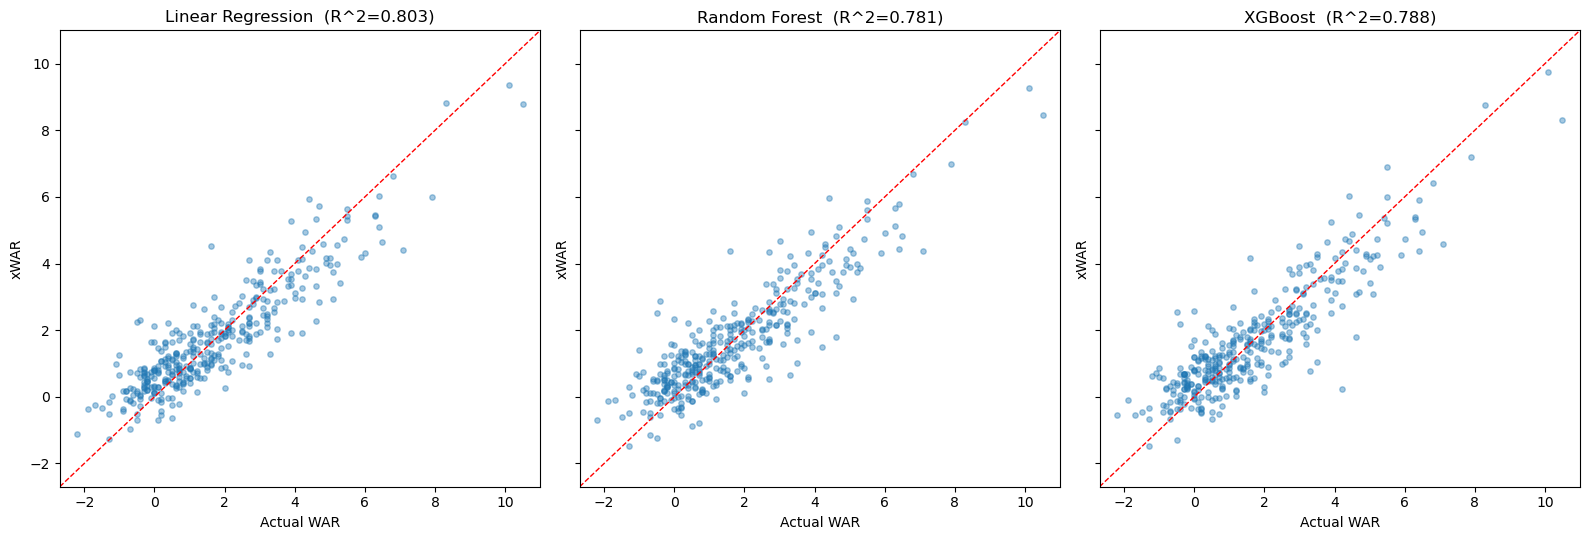

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharex=True, sharey=True)
labels = {'lin': 'Linear Regression', 'rf': 'Random Forest', 'xgb': 'XGBoost'}

lims = [
    min(test['war'].min(), *[test[f'xWAR_{t}'].min() for t in labels]) - 0.5,
    max(test['war'].max(), *[test[f'xWAR_{t}'].max() for t in labels]) + 0.5,
]

for ax, tag in zip(axes, labels):
    ax.scatter(test['war'], test[f'xWAR_{tag}'], alpha=0.4, s=15)
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual WAR')
    ax.set_ylabel('xWAR')
    ax.set_title(f"{labels[tag]}  (R^2={r2_score(test['war'], test[f'xWAR_{tag}']):.3f})")

plt.tight_layout()
plt.show()

In [16]:
# Top-20 leaderboard per model, test set only
for tag in ['lin', 'rf', 'xgb']:
    print(f'\nTOP 20 -- {labels[tag]} xWAR (test set)')
    print(
        test[['name', 'season', 'pos', f'xWAR_{tag}', 'war']]
        .sort_values(f'xWAR_{tag}', ascending=False)
        .head(20)
        .to_string(index=False)
    )


TOP 20 -- Linear Regression xWAR (test set)
                 name  season pos  xWAR_lin     war
          Aaron Judge    2025  RF    9.3510 10.1000
            Juan Soto    2024  RF    8.8144  8.3000
       Bobby Witt Jr.    2024  SS    8.7902 10.5000
   Fernando Tatis Jr.    2021  SS    6.6316  6.8000
         Jose Ramirez    2021  3B    6.0236  6.4000
     Gunnar Henderson    2024  SS    5.9962  7.9000
         Corey Seager    2022  SS    5.9244  4.4000
       Alejandro Kirk    2025   C    5.7337  4.7000
    William Contreras    2024   C    5.6408  5.5000
Vladimir Guerrero Jr.    2021  1B    5.4534  6.3000
     Francisco Lindor    2023  SS    5.4384  5.5000
          Ketel Marte    2024  2B    5.4133  6.3000
         Corey Seager    2024  SS    5.3226  4.6000
          Aaron Judge    2021  RF    5.3115  5.5000
Vladimir Guerrero Jr.    2025  1B    5.2627  3.9000
         Corey Seager    2023  SS    5.0879  6.4000
       Patrick Bailey    2024   C    4.9475  4.3000
         Alex Bregm

## Step 11 — Apply all three calibrated pipelines to the full dataset and export

Refits nothing — reuses the already-fit hitting/baserunning models and Step 7's calibrated constants,
just predicts on `master` (train + test combined) so every player-season gets an xWAR from all three
models.

In [17]:
full = master.copy()
full['league_woba'] = full['season'].map(league_woba)

# wOBA predictions, all three models
full['xwoba_lin'] = lin_hit.predict(full[hit_features])
full['xwoba_rf']  = rf_hit.predict(full[hit_features])
full['xwoba_xgb'] = xgb_hit.predict(full[hit_features])

# BsR predictions, all three models (each uses its own xwoba)
full['xbsr_lin'] = lin_run.predict(full[['sprint_speed', 'xwoba_lin', 'sb', 'cs']])
full['xbsr_rf']  = rf_run.predict(full[['sprint_speed', 'xwoba_rf', 'sb', 'cs']])
full['xbsr_xgb'] = xgb_run.predict(full[['sprint_speed', 'xwoba_xgb', 'sb', 'cs']])

# Fielding / positional / replacement -- model-independent, same as Steps 5-6
full['oaa_run_factor'] = full['pos'].map(OAA_TO_RUNS).fillna(0.80)
full['oaa_runs'] = full['oaa'] * full['oaa_run_factor']
full['fielding_runs'] = np.where(full['is_catcher'], full['frm'], full['oaa_runs']).astype(float)
full['fielding_runs'] = full['fielding_runs'].fillna(0)
full['pos_adj_runs'] = full['pos'].map(POSITIONAL_ADJ_PER_600).fillna(0) * (full['pa'] / 600)
full['replacement_runs'] = REPLACEMENT_RUNS_PER_600 * (full['pa'] / 600)

# RAR / xWAR for all three, each with its OWN calibrated WOBA_SCALE / RUNS_PER_WIN from Step 7
for tag in ['lin', 'rf', 'xgb']:
    full[f'raw_woba_diff_term_{tag}'] = (full[f'xwoba_{tag}'] - full['league_woba']) * full['pa']
    full[f'other_runs_{tag}'] = (
        full[f'xbsr_{tag}'] + full['fielding_runs'] + full['pos_adj_runs'] + full['replacement_runs']
    )
    full[f'RAR_{tag}'], full[f'xWAR_{tag}'] = compute_xwar(full, tag)

full['split'] = np.where(full.index.isin(test_idx), 'test', 'train')

export_cols = [
    'name', 'season', 'pos', 'pa', 'war', 'split',
    'xWAR_lin', 'xWAR_rf', 'xWAR_xgb',
]

full[export_cols].sort_values(['season', 'xWAR_lin'], ascending=[True, False]) \
    .to_csv('xwar_all_player_seasons_v5.csv', index=False)

print(f'Exported {len(full)} player-seasons to xwar_all_player_seasons_v5.csv')
print()
print('Calibrated constants used (from Step 7):')
print(calib_df[['WOBA_SCALE', 'RUNS_PER_WIN']].round(4))

Exported 1793 player-seasons to xwar_all_player_seasons_v5.csv

Calibrated constants used (from Step 7):
     WOBA_SCALE  RUNS_PER_WIN
tag                          
lin      1.2620        9.5584
rf       1.0580       10.0598
xgb      1.1282        9.9516


## Notes / next steps

- **v5 feature removal summary**: `ev`, `maxev`, `pull` (hitting model) and `sb_pct` (baserunning
  model) were removed after a p-value + VIF review. `maxev`/`pull` were not statistically significant
  (p=0.297 and p=0.164); `ev`/`maxev`/`ev90` had VIF in the thousands (near-duplicate exit-velocity
  measurements); `sb_pct` was a redundant function of `sb`/`cs`, both already in the model. Held-out
  wOBA R² moved by < 0.002 from dropping all of them — negligible skill loss for a meaningfully cleaner,
  less collinear model.
- **`la` (launch angle)** was borderline (p=0.055) in the review and was kept — it's right at the
  significance boundary and is a real, interpretable skill signal, so it wasn't cut alongside the
  clearly-insignificant features. Worth re-checking if the dataset grows.
- **Per-model calibration vs one shared calibration**: this notebook calibrates `WOBA_SCALE` /
  `RUNS_PER_WIN` separately for each of lin/rf/xgb. If you'd rather lock in one set of constants
  (e.g. once you've picked a final model) and apply it everywhere for consistency with public WAR
  conventions, just reuse `calibration['lin']` (or whichever model you settle on) instead of each
  model's own.
- **Collinearity check**: worth explicitly running
  `train[['raw_woba_diff_term_lin', 'other_runs_lin']].corr()` (and the rf/xgb equivalents) to confirm
  the two calibrated coefficients aren't trading off against each other.
- **`fit_intercept=False` is deliberate** in the calibration step — see Step 7 for why.
- **Unused remaining peripherals**: `bolts`, `bolts_pct`, `hp_to_1b`, `competitive_runs` were never
  brought into this notebook's aggregation step at all, since earlier testing showed mixed/marginal
  results once SB/CS were already included. They're still in the raw `expectedwar.csv` if you want to
  re-test them.
- **Data quality**: re-run a spot check on the dedup step in Step 1 if the dataset grows past 2025, in
  case the same mid-season-trade merge issue recurs at larger scale.
- **Scoring new data**: this notebook only trains and validates against 2021–2025. To score any new
  dataset (a future season, a subset of players, etc.) against the finalized linear models, use the
  companion `xWAR_test_new_data.ipynb` notebook instead of adding a cell here.